# DustSCAN Multi-Year Exploratory Data Analysis

**Overview**  
This notebook analyzes two years of data (`DustSCAN_2021.nc` and `DustSCAN_2022.nc`) to extract seasonal trends, spatial distributions, diurnal cycles, and physical feature characteristics of dust storms across multiple years.

## 1. Environment Setup & Multi-Year Data Loading

In [1]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

# Load the dataset for both years
file_paths = [
    os.path.expanduser('~/Downloads/DustSCAN_2021.nc'),
    os.path.expanduser('~/Downloads/DustSCAN_2022.nc')
]

try:
    # Use parallel=False if dask is not fully configured for local large loading, 
    # but combine='nested' and concat_dim='time' is necessary for xarray
    ds = xr.open_mfdataset(file_paths, engine='netcdf4', combine='nested', concat_dim='time', parallel=False)
    print("Multi-year datasets loaded successfully.")
    
    # Create boolean mask for dust presence (target is plume_id > 0)
    is_dust = ds['plume_id'] > 0
    print(f"Total time steps loaded: {len(ds['time'])}")
except Exception as e:
    print(f"Error loading datasets: {e}")


Multi-year datasets loaded successfully.
Total time steps loaded: 17432


---
## 2. Temporal Analysis: Inter-Annual & Seasonal Trends

We compare the overall dust frequency between 2021 and 2022 and plot their seasonal (monthly) distributions side-by-side.

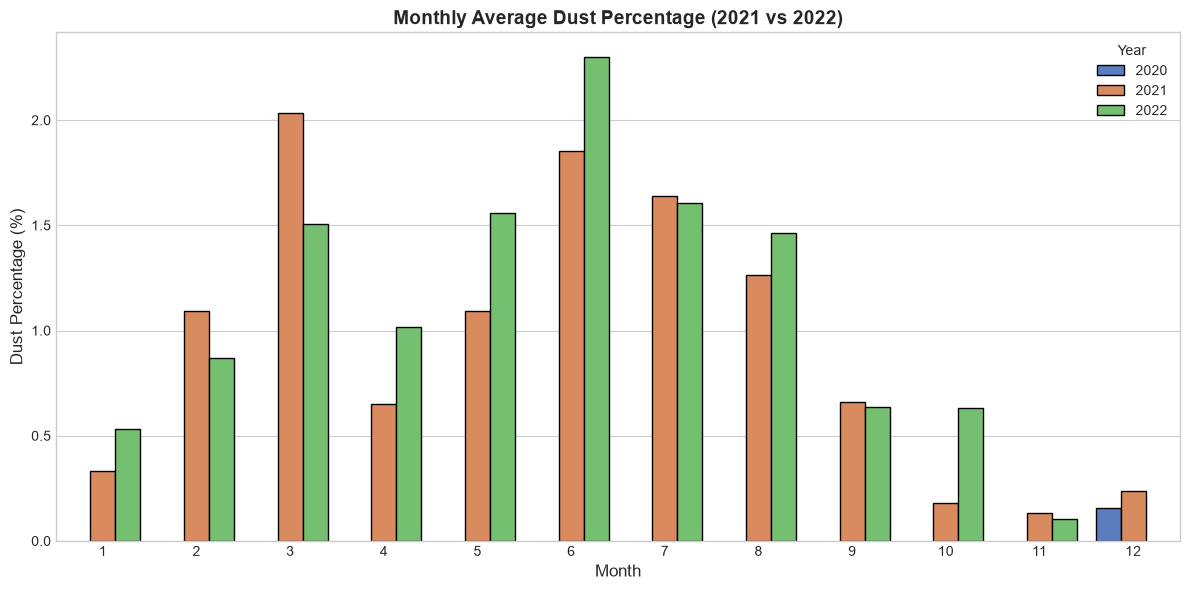

C:\Users\sai siddharth\AppData\Local\Temp\ipykernel_38848\722645229.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_yearly, x='year', y='is_dust', palette='pastel', edgecolor='black')


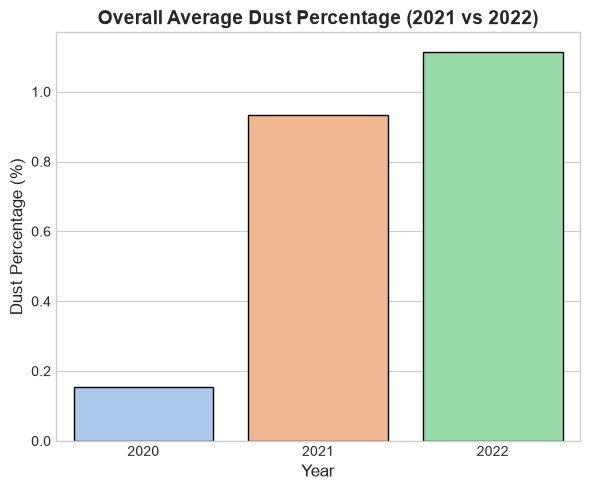

In [2]:
# Group by year and month
dust_monthly = is_dust.groupby('time.month').mean(dim=['time', 'lat', 'lon']).compute() * 100

# Create a DataFrame grouped by year and month
times = pd.to_datetime(ds['time'].values)
df_time = pd.DataFrame({'time': times, 'is_dust': is_dust.mean(dim=['lat', 'lon']).compute().values * 100})
df_time['year'] = df_time['time'].dt.year
df_time['month'] = df_time['time'].dt.month

df_monthly_yearly = df_time.groupby(['year', 'month'])['is_dust'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_monthly_yearly, x='month', y='is_dust', hue='year', palette='muted', edgecolor='black')
plt.title('Monthly Average Dust Percentage (2021 vs 2022)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Dust Percentage (%)', fontsize=12)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

# Inter-annual overall comparison
df_yearly = df_time.groupby('year')['is_dust'].mean().reset_index()
plt.figure(figsize=(6, 5))
sns.barplot(data=df_yearly, x='year', y='is_dust', palette='pastel', edgecolor='black')
plt.title('Overall Average Dust Percentage (2021 vs 2022)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Dust Percentage (%)', fontsize=12)
plt.tight_layout()
plt.show()


---
## 3. Spatial Distribution of Dust

Calculate the geographic zones that are most affected by dust across the combined two-year dataset.

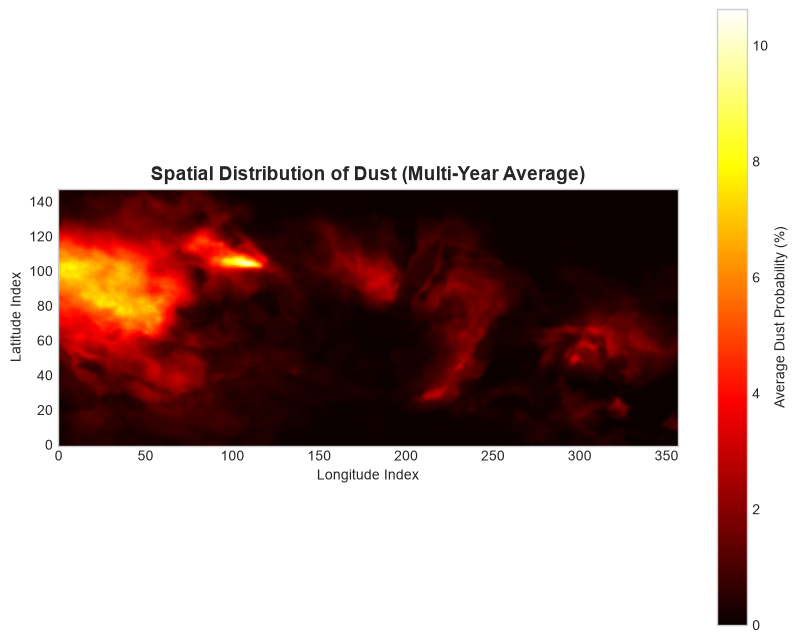

In [3]:
# Calculate mean dust presence across time
dust_spatial = is_dust.mean(dim='time').compute()

plt.figure(figsize=(10, 8))
plt.imshow(dust_spatial.values * 100, cmap='hot', origin='lower')
plt.colorbar(label='Average Dust Probability (%)')
plt.title('Spatial Distribution of Dust (Multi-Year Average)', fontsize=14, fontweight='bold')
plt.xlabel('Longitude Index')
plt.ylabel('Latitude Index')
plt.grid(False)
plt.show()


---
## 4. Diurnal Cycle Analysis

How does dust presence fluctuate over a standard 24-hour cycle? We plot this trend grouped by year to see if the diurnal patterns remain consistent.

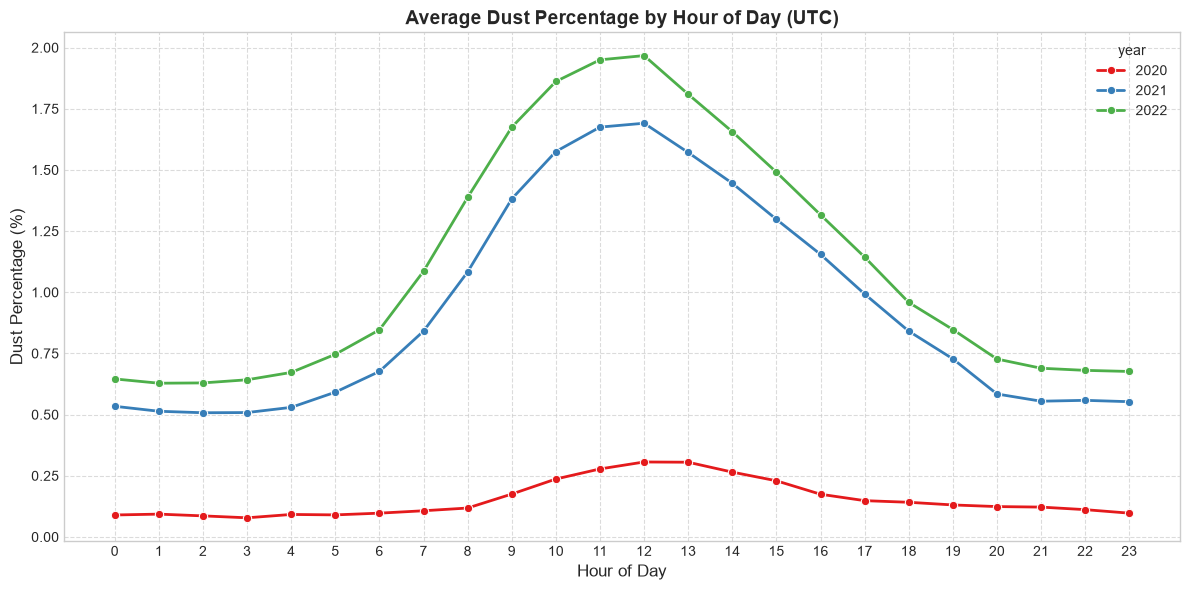

In [4]:
df_time['hour'] = df_time['time'].dt.hour
df_hourly = df_time.groupby(['year', 'hour'])['is_dust'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_hourly, x='hour', y='is_dust', hue='year', marker='o', linewidth=2, palette='Set1')
plt.title('Average Dust Percentage by Hour of Day (UTC)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Dust Percentage (%)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


---
## 5. Feature Distributions: PDI and Sun Zenith

We subsample the combined massive dataset to compare physical attributes (Pink Dust Index and Sun Zenith angle) for pixels marked as dust versus those that are clear.

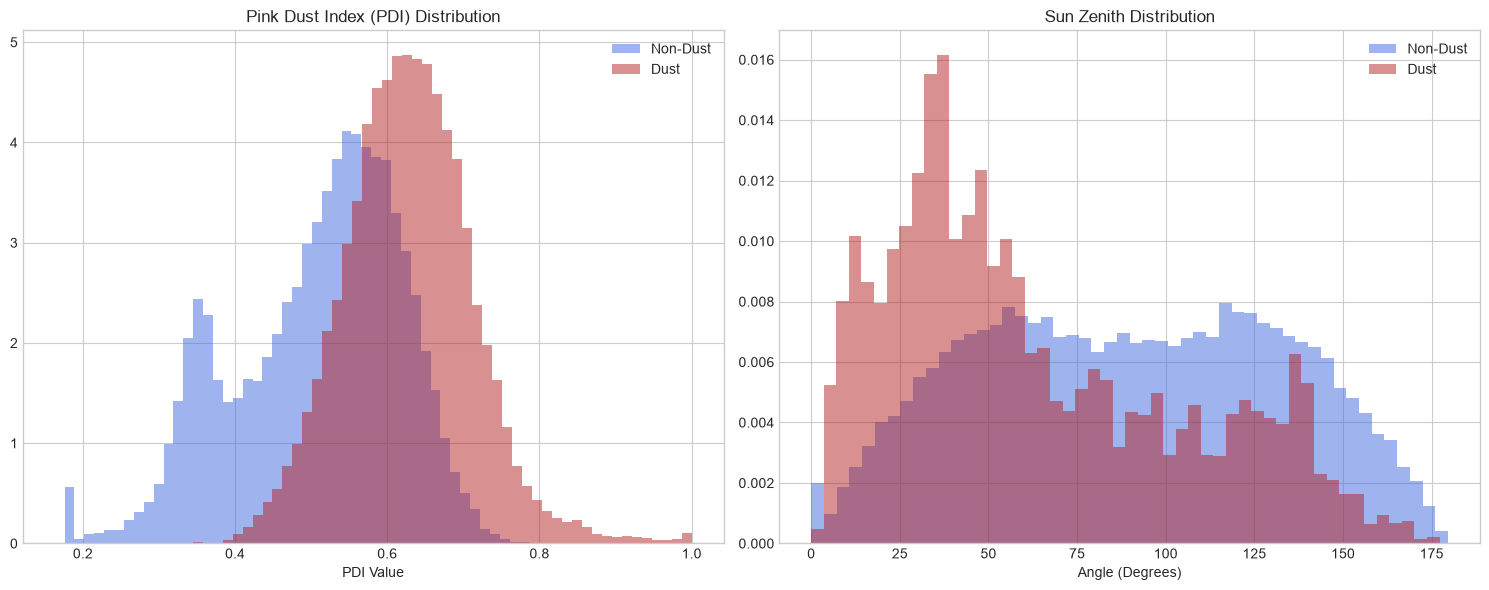

In [5]:
# Subsample data to save memory (every 50th timestep)
ds_sub = ds.isel(time=slice(0, None, 50)).compute()
is_dust_sub = ds_sub['plume_id'] > 0

pdi_values = ds_sub['pdi'].values.flatten()
sun_zenith_values = ds_sub['sun_zenith'].values.flatten()
dust_mask_values = is_dust_sub.values.flatten()

# Filter NaNs
valid_mask = ~np.isnan(pdi_values) & ~np.isnan(sun_zenith_values)
pdi_valid = pdi_values[valid_mask]
sun_zenith_valid = sun_zenith_values[valid_mask]
dust_valid = dust_mask_values[valid_mask]

# Sample equally for fast visualization
sample_size = min(50000, np.sum(dust_valid))

# Indices for dust and non-dust
dust_idx = np.where(dust_valid)[0]
nondust_idx = np.where(~dust_valid)[0]

sample_dust = np.random.choice(dust_idx, sample_size, replace=False)
sample_nondust = np.random.choice(nondust_idx, sample_size, replace=False)

fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# PDI
axs[0].hist(pdi_valid[sample_nondust], bins=50, alpha=0.5, label='Non-Dust', density=True, color='royalblue')
axs[0].hist(pdi_valid[sample_dust], bins=50, alpha=0.5, label='Dust', density=True, color='firebrick')
axs[0].set_title('Pink Dust Index (PDI) Distribution')
axs[0].set_xlabel('PDI Value')
axs[0].legend()

# Sun Zenith
axs[1].hist(sun_zenith_valid[sample_nondust], bins=50, alpha=0.5, label='Non-Dust', density=True, color='royalblue')
axs[1].hist(sun_zenith_valid[sample_dust], bins=50, alpha=0.5, label='Dust', density=True, color='firebrick')
axs[1].set_title('Sun Zenith Distribution')
axs[1].set_xlabel('Angle (Degrees)')
axs[1].legend()

plt.tight_layout()
plt.show()


---
## 6. Cloud Mask Interaction

Understanding the intersection between cloud coverage and dust detection across the multi-year dataset.

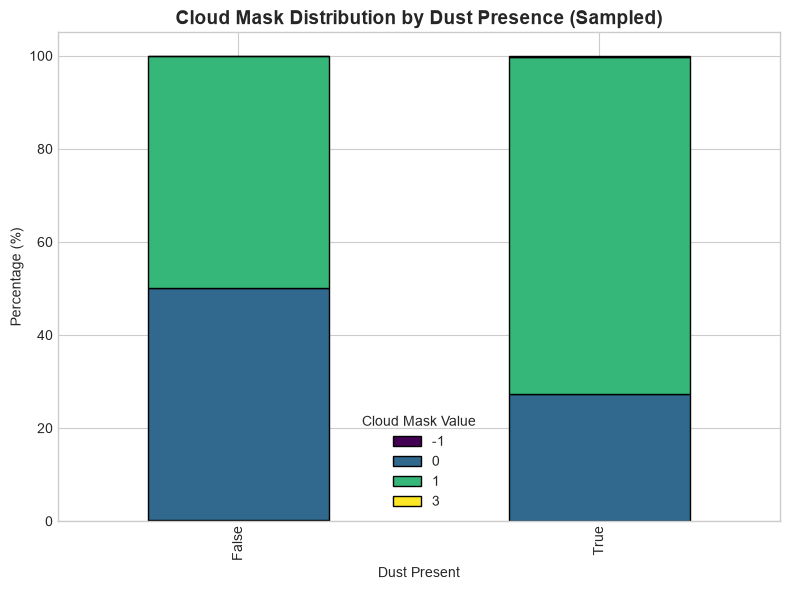

In [6]:
cloud_mask_values = ds_sub['cloud_mask'].values.flatten()[valid_mask]

df_clouds = pd.DataFrame({
    'Is_Dust': dust_valid[np.concatenate((sample_nondust, sample_dust))],
    'Cloud_Mask': cloud_mask_values[np.concatenate((sample_nondust, sample_dust))]
})

ct = pd.crosstab(df_clouds['Is_Dust'], df_clouds['Cloud_Mask'], normalize='index') * 100

ct.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='viridis', edgecolor='black')
plt.title('Cloud Mask Distribution by Dust Presence (Sampled)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xlabel('Dust Present')
plt.legend(title='Cloud Mask Value')
plt.tight_layout()
plt.show()


### Sun Zenith Analysis
Let's analyze how the sun zenith angle varies over a single day and across the entire year.

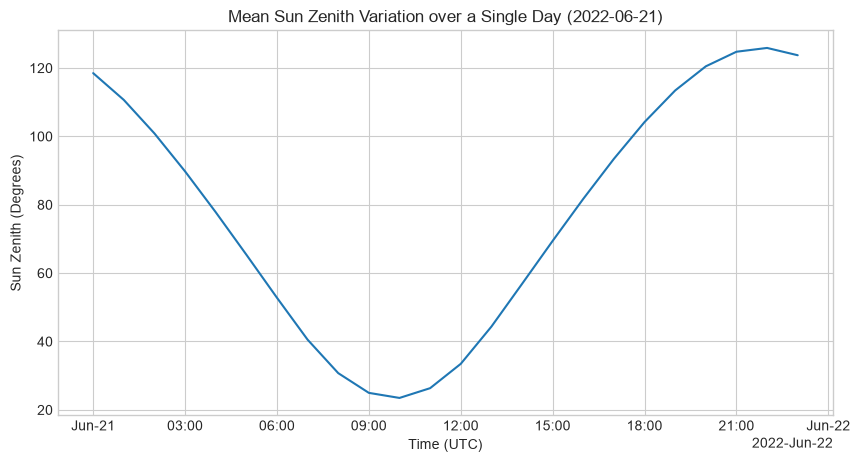

In [7]:
import matplotlib.pyplot as plt
import xarray as xr

# Load the dataset if it's not already loaded
file_path = 'C:/Users/sai siddharth/Downloads/DustSCAN_2022.nc'
ds_sun = xr.open_dataset(file_path, engine='netcdf4')

# 1. Variation of sun_zenith in a single day
# Let's pick a specific day (e.g., June 21)
day_data = ds_sun['sun_zenith'].sel(time=slice('2022-06-21 00:00:00', '2022-06-21 23:59:59'))

# We compute the mean over latitude and longitude for a general picture
day_mean = day_data.mean(dim=['lat', 'lon'])

plt.figure(figsize=(10, 5))
day_mean.plot()
plt.title('Mean Sun Zenith Variation over a Single Day (2022-06-21)')
plt.xlabel('Time (UTC)')
plt.ylabel('Sun Zenith (Degrees)')
plt.grid(True)
plt.show()


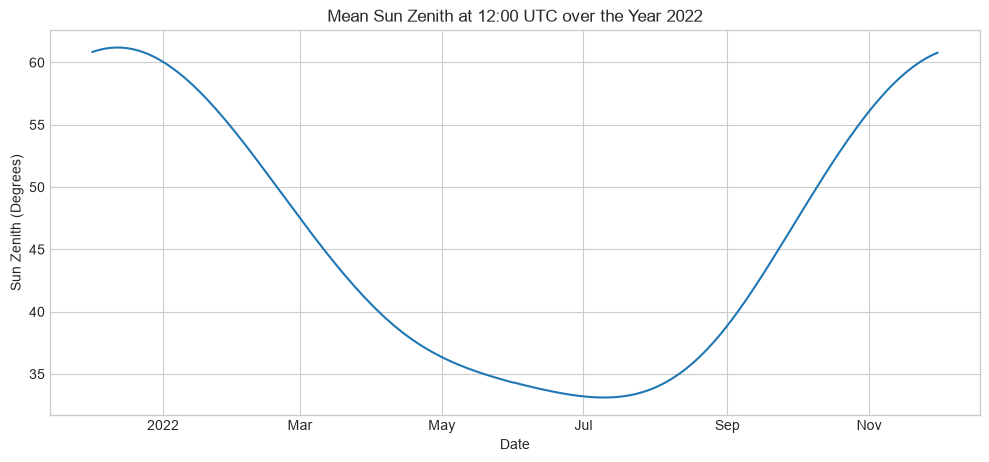

In [8]:
# 2. Variation of sun_zenith over the entire year
# We will select 12:00 UTC for each day to track the seasonal variation
noon_data = ds_sun['sun_zenith'].sel(time=ds_sun['time'].dt.hour == 12)
noon_mean = noon_data.mean(dim=['lat', 'lon'])

plt.figure(figsize=(12, 5))
noon_mean.plot()
plt.title('Mean Sun Zenith at 12:00 UTC over the Year 2022')
plt.xlabel('Date')
plt.ylabel('Sun Zenith (Degrees)')
plt.grid(True)
plt.show()
